In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/store.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [ ]:
int_cols = ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'Promo2SinceYear']
df[int_cols] = df[int_cols].fillna(-1).astype(int)

In [ ]:
df.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [4]:
df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
df.StoreType.value_counts() / df.shape[0]

StoreType
a    0.539910
d    0.312108
c    0.132735
b    0.015247
Name: count, dtype: float64

In [7]:
df.Assortment.value_counts() / df.shape[0]

Assortment
a    0.531839
c    0.460090
b    0.008072
Name: count, dtype: float64

In [20]:
df.CompetitionOpenSinceMonth.value_counts() / df.shape[0]

CompetitionOpenSinceMonth
-1     0.317489
 9     0.112108
 4     0.084305
 11    0.082511
 3     0.062780
 7     0.060090
 12    0.057399
 10    0.054709
 6     0.044843
 5     0.039462
 2     0.036771
 8     0.034978
 1     0.012556
Name: count, dtype: float64

In [21]:
df.CompetitionOpenSinceYear.value_counts() / df.shape[0]

CompetitionOpenSinceYear
-1       0.317489
 2013    0.074439
 2012    0.073543
 2014    0.062780
 2005    0.055605
 2010    0.049327
 2008    0.048430
 2011    0.048430
 2009    0.048430
 2007    0.043049
 2006    0.042152
 2015    0.034081
 2002    0.024215
 2004    0.019731
 2003    0.017040
 2001    0.014350
 2000    0.008969
 1999    0.007175
 1990    0.004484
 1995    0.001794
 1994    0.001794
 1961    0.000897
 1900    0.000897
 1998    0.000897
Name: count, dtype: float64

In [22]:
df.Promo2SinceWeek.value_counts() / df.shape[0]

Promo2SinceWeek
-1     0.487892
 14    0.072646
 40    0.069058
 31    0.039462
 10    0.037668
 5     0.034978
 37    0.031390
 1     0.031390
 13    0.030493
 45    0.030493
 22    0.029596
 18    0.026009
 35    0.022422
 9     0.012556
 27    0.009865
 36    0.008969
 48    0.008072
 39    0.005381
 23    0.004484
 44    0.002691
 6     0.000897
 26    0.000897
 50    0.000897
 49    0.000897
 28    0.000897
Name: count, dtype: float64

In [23]:
df.Promo2SinceYear.value_counts() / df.shape[0]

Promo2SinceYear
-1       0.487892
 2011    0.114798
 2013    0.107623
 2014    0.085202
 2012    0.072646
 2009    0.065471
 2010    0.057399
 2015    0.008969
Name: count, dtype: float64

In [24]:
df.PromoInterval.value_counts() / df.shape[0]

PromoInterval
Jan,Apr,Jul,Oct     0.300448
Feb,May,Aug,Nov     0.116592
Mar,Jun,Sept,Dec    0.095067
Name: count, dtype: float64

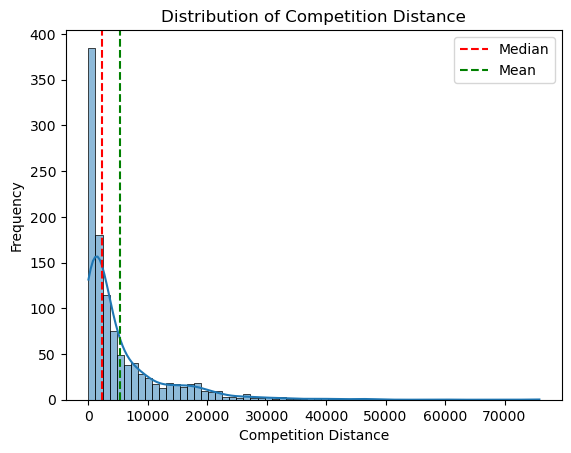

In [10]:
med = df['CompetitionDistance'].median()
avg = df['CompetitionDistance'].mean()

sns.histplot(data=df, x='CompetitionDistance', kde=True)
plt.axvline(med, color='r', linestyle='--', label='Median')
plt.axvline(avg, color='g', linestyle='--', label='Mean')
plt.title('Distribution of Competition Distance')
plt.xlabel('Competition Distance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [15]:
# Since we have a left skewed distribution of competion distance,
# let's transform it to log and square root and see which yield similarity
# to a normal/gaussian distribution
min_dist_val = df['CompetitionDistance'].min()
df['Log_CompetitionDistance'] = np.log(df['CompetitionDistance']  + 1)
df['Sqrt_CompetitionDistance'] = np.sqrt(df['CompetitionDistance'])

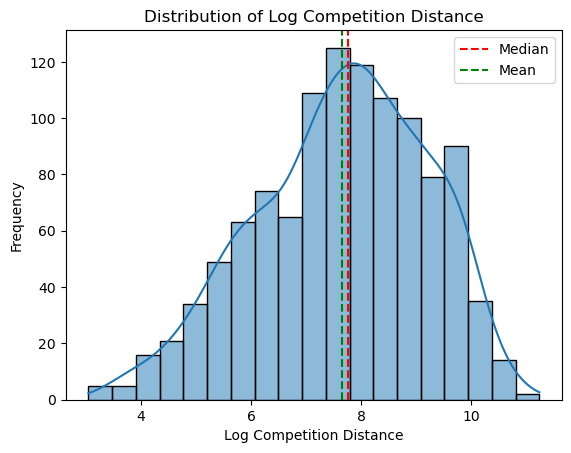

In [16]:
med = df['Log_CompetitionDistance'].median()
avg = df['Log_CompetitionDistance'].mean()

sns.histplot(data=df, x='Log_CompetitionDistance', kde=True)
plt.axvline(med, color='r', linestyle='--', label='Median')
plt.axvline(avg, color='g', linestyle='--', label='Mean')
plt.title('Distribution of Log Competition Distance')
plt.xlabel('Log Competition Distance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

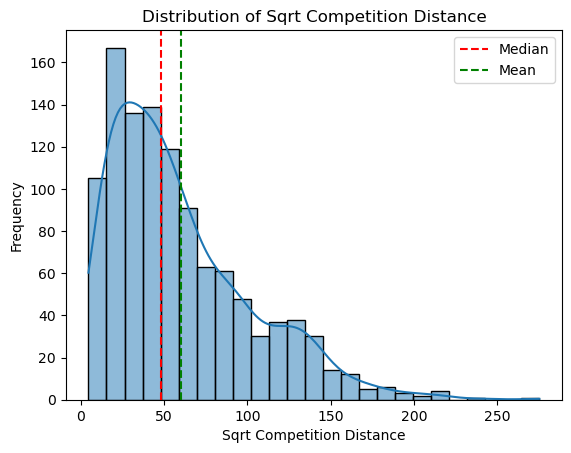

In [14]:
med = df['Sqrt_CompetitionDistance'].median()
avg = df['Sqrt_CompetitionDistance'].mean()

sns.histplot(data=df, x='Sqrt_CompetitionDistance', kde=True)
plt.axvline(med, color='r', linestyle='--', label='Median')
plt.axvline(avg, color='g', linestyle='--', label='Mean')
plt.title('Distribution of Sqrt Competition Distance')
plt.xlabel('Sqrt Competition Distance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# We can clearly see that the log transformaation resembles a more normal distribution than sqrt transformation.